# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sumit07-git/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## 1. Question

### Research question

Can historical content and search-performance signals be used to prioritize
content items associated with an observed performance decline for human
review?

### Decision supported

The goal is to help a content team decide which content items should be
reviewed first. The model provides a ranked, directional priority list
rather than an automatic decision about which pages should be changed.

The analysis focuses on measured associations in the available dataset.
It does not attempt to prove causation or reproduce any search engine's
ranking algorithm.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

The analysis uses the FlyRank ML Internship modeling dataset available
through the internship repository and warehouse workflow.

The modeling dataset contains anonymized content-level observations and
historical performance features.

The modeling workflow uses the following fields:

- impressions_90d
- clicks_90d
- sessions_90d
- avg_position
- engagement_rate

The observed decline label is constructed from trend_direction:

- down → 1, declining
- all other observed categories → 0, not declining

The fields trend_direction and trend_pct are excluded from the model
features because they directly describe the observed outcome and could
create target leakage.

The data is pseudonymized and no client names, domains, private queries,
credentials, or raw client exports are used in the analysis.

The ML-04 data contract also identified uneven historical coverage and
uneven GA4 availability as important data limitations.

In [2]:
!git clone https://github.com/Sumit07-git/flyrank-ml-internship.git

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 164, done.
remote: Counting objects: 100% (164/164), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 164 (delta 72), reused 94 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (164/164), 1.91 MiB | 18.62 MiB/s, done.
Resolving deltas: 100% (72/72), done.


In [3]:
!find /content/flyrank-ml-internship -name "content_refresh_anonymized.csv"

/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (30000, 44)


In [5]:
df["is_declining"] = (
    df["trend_direction"] == "down"
).astype(int)

print("\nTarget distribution:")
display(
    df["is_declining"]
    .value_counts()
    .rename_axis("is_declining")
    .reset_index(name="count")
)


Target distribution:


,is_declining,count
0,1,16262
1,0,13738


In [7]:
features = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "avg_position",
    "engagement_rate"
]

target = "is_declining"

print("Features:")
for feature in features:
    print("-", feature)

print("\nTarget:", target)

Features:
- impressions_90d
- clicks_90d
- sessions_90d
- avg_position
- engagement_rate

Target: is_declining


In [8]:
print("Dataset shape:", df.shape)

print("\nTarget distribution:")
display(
    df["is_declining"]
    .value_counts()
    .rename_axis("is_declining")
    .reset_index(name="rows")
)

print("\nFinal features:")
for feature in features:
    print("-", feature)

Dataset shape: (30000, 45)

Target distribution:


,is_declining,rows
0,1,16262
1,0,13738



Final features:
- impressions_90d
- clicks_90d
- sessions_90d
- avg_position
- engagement_rate


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

### Features

The model uses five historical/content performance features:

1. impressions_90d
2. clicks_90d
3. sessions_90d
4. avg_position
5. engagement_rate

### Label

The target is `is_declining`, a binary proxy derived from the observed
`trend_direction` field.

An observation is labeled 1 when its trend direction is `down`; other
observed trend categories are labeled 0.

### Model

The modeling method is a Random Forest classifier with:

- 300 trees
- fixed random seed of 42
- balanced class weights

### Baseline

The baseline is the existing heuristic score based on content freshness
and visibility. It prioritizes content that is at least 180 days since its
last update and has at least 500 impressions over the 90-day period.

### Validation

The initial ML-08 model used a random 80/20 train/test split.

ML-09 added a stricter grouped-by-client validation, keeping observations
from the same client out of both training and testing groups.

The grouped validation is used as the more conservative validation result
because it tests generalization across clients.

### Leakage checks

The final feature set was audited against the target and outcome-derived
fields. `is_declining`, `trend_direction`, and `trend_pct` were not used as
model features.

The results are interpreted as measured, directional decision-support
evidence rather than causal evidence.

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

print("Model:", model)
print("Number of features:", len(features))

Model: RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)
Number of features: 5


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

The model was evaluated using Precision@K, which measures the proportion
of the top K ranked content items that have the observed declining label.

The grouped validation produced higher Precision@10 and Precision@20 than
the random split, while Precision@50 was lower.

The results therefore vary by ranking depth. The model should not be
described as uniformly better under the stricter validation design.

A separate model-versus-baseline comparison on the same evaluation split
is used for the final baseline claim.

In [10]:
validation_results = pd.DataFrame({
    "K": [10, 20, 50],
    "Random Split Precision@K": [0.80, 0.70, 0.82],
    "Grouped-by-Client Precision@K": [1.00, 0.85, 0.72]
})

display(validation_results)

,K,Random Split Precision@K,Grouped-by-Client Precision@K
0,10,0.80,1.00
1,20,0.70,0.85
2,50,0.82,0.72


## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This analysis has several important limitations.

First, `is_declining` is a proxy label constructed from the observed
`trend_direction` field. It represents an observed outcome in the dataset,
not a complete definition of content quality.

Second, the model identifies directional associations and ranking
patterns. It does not establish that changing any feature will cause
search performance to improve.

Third, validation results vary by ranking depth. The grouped validation
performed better at K=10 and K=20 but worse at K=50 compared with the
random split.

Fourth, historical data coverage is uneven across observations. GA4
availability also varies, so missing or zero-filled values should not
always be interpreted as genuine zero activity.

Finally, the model should not be interpreted as evidence about Google's
ranking algorithm, nor should its recommendations be treated as
guaranteed refresh outcomes.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

model.fit(
    df[features],
    df[target]
)

df["model_score"] = model.predict_proba(
    df[features]
)[:, 1]

print("Model trained and scores generated.")

Model trained and scores generated.


In [17]:
def get_reason_code(row):
    reasons = []

    if row["model_score"] >= 0.80:
        reasons.append("HIGH_DECLINE_SCORE")

    if row["days_since_last_update"] >= 180:
        reasons.append("STALE_CONTENT")

    if row["impressions_90d"] >= 500:
        reasons.append("VISIBLE_CONTENT")

    if row["avg_position"] >= 10:
        reasons.append("WEAKER_SEARCH_POSITION")

    if row["engagement_rate"] < df["engagement_rate"].median():
        reasons.append("LOWER_ENGAGEMENT")

    if not reasons:
        reasons.append("MODEL_REVIEW")

    return " | ".join(reasons)

In [18]:
def get_action(row):
    if (
        row["model_score"] >= 0.80
        and row["days_since_last_update"] >= 180
        and row["impressions_90d"] >= 500
    ):
        return "PRIORITIZE_REFRESH"

    if row["model_score"] >= 0.60:
        return "REVIEW"

    return "MONITOR"

In [19]:
queue = df.copy()

queue["reason_code"] = queue.apply(
    get_reason_code,
    axis=1
)

queue["recommended_action"] = queue.apply(
    get_action,
    axis=1
)

queue = queue.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

queue["rank"] = range(1, len(queue) + 1)

print("Queue created:", queue.shape)

Queue created: (30000, 49)


In [20]:
queue_columns = [
    "rank",
    "content_id",
    "model_score",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "reason_code",
    "recommended_action"
]

display(
    queue[queue_columns].head(20)
)

,rank,content_id,model_score,days_since_last_update,impressions_90d,avg_position,reason_code,recommended_action
0,1,content_baa7232f4846,1.000000,20,239,7.8,HIGH_DECLINE_SCORE,REVIEW
1,2,content_1b74b27f23b9,1.000000,104,408,2.9,HIGH_DECLINE_SCORE,REVIEW
2,3,content_3f7335f23833,1.000000,20,1073,5.2,HIGH_DECLINE_SCORE | VISIBLE_CONTENT,REVIEW
3,4,content_d5b833d82e72,1.000000,20,1220,7.5,HIGH_DECLINE_SCORE | VISIBLE_CONTENT,REVIEW
4,5,content_20b682542a31,1.000000,20,339,3.3,HIGH_DECLINE_SCORE,REVIEW
5,6,content_aa9b17a4ea86,1.000000,20,310,2.9,HIGH_DECLINE_SCORE,REVIEW
6,7,content_096c9f804d01,1.000000,19,954,2.7,HIGH_DECLINE_SCORE | VISIBLE_CONTENT,REVIEW
7,8,content_03c957094bba,1.000000,20,9449,3.1,HIGH_DECLINE_SCORE | VISIBLE_CONTENT,REVIEW
8,9,content_e1bdad640bcf,1.000000,20,1532,8.0,HIGH_DECLINE_SCORE | VISIBLE_CONTENT,REVIEW
9,10,content_9412afc8a975,1.000000,104,306,22.5,HIGH_DECLINE_SCORE | WEAKER_SEARCH_POSITION,REVIEW


In [21]:
import os

os.makedirs(
    "/content/flyrank-ml-internship/outputs",
    exist_ok=True
)

queue_path = (
    "/content/flyrank-ml-internship/outputs/"
    "content_action_queue.csv"
)

queue[queue_columns].to_csv(
    queue_path,
    index=False
)

print("Saved:", queue_path)

Saved: /content/flyrank-ml-internship/outputs/content_action_queue.csv


In [22]:
import os

print(
    os.path.exists(queue_path),
    queue_path
)

True /content/flyrank-ml-internship/outputs/content_action_queue.csv


In [23]:
queue_path = "/content/flyrank-ml-internship/outputs/content_action_queue.csv"

queue = pd.read_csv(queue_path)

print("Queue shape:", queue.shape)

display(queue.head(20))

Queue shape: (30000, 8)


,rank,content_id,model_score,days_since_last_update,impressions_90d,avg_position,reason_code,recommended_action
0,1,content_baa7232f4846,1.000000,20,239,7.8,HIGH_DECLINE_SCORE,REVIEW
1,2,content_1b74b27f23b9,1.000000,104,408,2.9,HIGH_DECLINE_SCORE,REVIEW
2,3,content_3f7335f23833,1.000000,20,1073,5.2,HIGH_DECLINE_SCORE | VISIBLE_CONTENT,REVIEW
3,4,content_d5b833d82e72,1.000000,20,1220,7.5,HIGH_DECLINE_SCORE | VISIBLE_CONTENT,REVIEW
4,5,content_20b682542a31,1.000000,20,339,3.3,HIGH_DECLINE_SCORE,REVIEW
5,6,content_aa9b17a4ea86,1.000000,20,310,2.9,HIGH_DECLINE_SCORE,REVIEW
6,7,content_096c9f804d01,1.000000,19,954,2.7,HIGH_DECLINE_SCORE | VISIBLE_CONTENT,REVIEW
7,8,content_03c957094bba,1.000000,20,9449,3.1,HIGH_DECLINE_SCORE | VISIBLE_CONTENT,REVIEW
8,9,content_e1bdad640bcf,1.000000,20,1532,8.0,HIGH_DECLINE_SCORE | VISIBLE_CONTENT,REVIEW
9,10,content_9412afc8a975,1.000000,104,306,22.5,HIGH_DECLINE_SCORE | WEAKER_SEARCH_POSITION,REVIEW


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

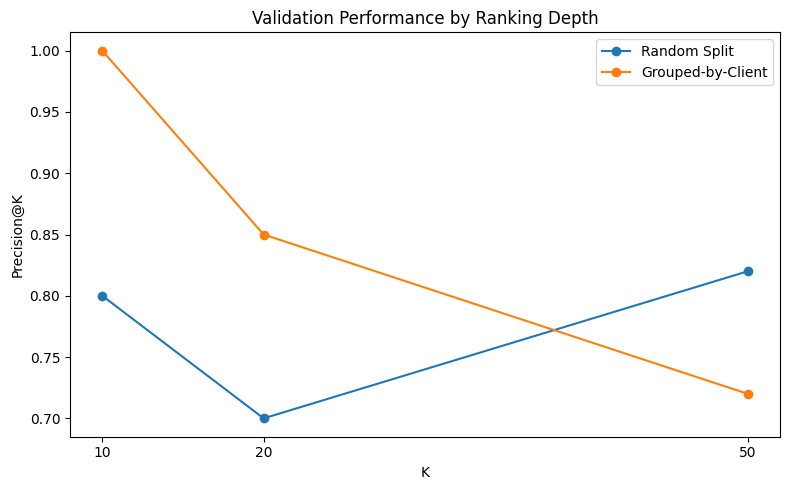

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    validation_results["K"],
    validation_results["Random Split Precision@K"],
    marker="o",
    label="Random Split"
)

plt.plot(
    validation_results["K"],
    validation_results["Grouped-by-Client Precision@K"],
    marker="o",
    label="Grouped-by-Client"
)

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Validation Performance by Ranking Depth")
plt.xticks([10, 20, 50])
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(importance_df)

,feature,importance
0,impressions_90d,0.356989
3,avg_position,0.351896
2,sessions_90d,0.144143
1,clicks_90d,0.086625
4,engagement_rate,0.060347


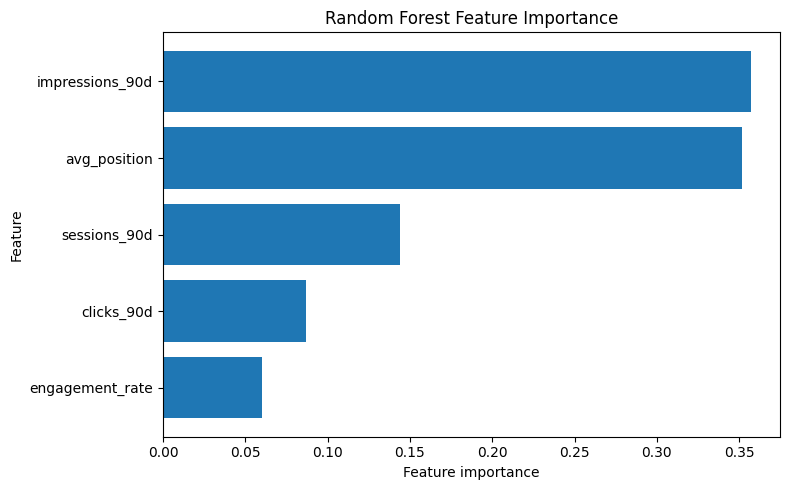

In [26]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# **ML-12 closing cells**

## ML-12 — 5-minute demo outline

###  Problem

Explain the decision: prioritize content items for human review when
historical signals are associated with an observed decline.

###  Data

Explain the anonymized content-level dataset, five model features, and
the observed decline proxy.

###  Method

Explain the Random Forest model, baseline, grouped validation, and leakage
audit.

###  Results

Show the Precision@K comparison and explain how results changed between
random and grouped validation.

###  Action playbook

Show the ranked recommendations, reason codes, and human-review actions.

###  Honest conclusion

Explain that the result is directional decision-support and does not prove
causation or reproduce a search engine's ranking system.

# Social-post cut

## Social-post cut

Built a Search Intelligence capstone using anonymized FlyRank data.

I trained a Random Forest model to prioritize content associated with an
observed performance decline, compared it with a baseline, audited
leakage, and tested the model with grouped-by-client validation.

The result is a ranked, human-review action queue rather than an automatic
content decision system.

The biggest lesson: validation design matters. Model performance changed
depending on ranking depth and the split strategy, so I treated the result
as directional decision-support rather than making causal claims.

# Employer-facing summary

## Employer-facing summary

Built an end-to-end Search Intelligence modeling workflow using anonymized
content-performance data. Developed a Random Forest ranking model,
compared it with a heuristic baseline, performed grouped validation and
leakage auditing, and converted model scores into a ranked action playbook.
The project demonstrates practical ML workflow skills including feature
design, validation, model interpretation, error analysis, and
decision-support communication.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
